In [30]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [31]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int

    number3: int
    operation2: str
    number4: int

    finalNumber: int
    finalNumber2: int

In [ ]:

def adder(state: AgentState) -> AgentState:
    """This node adds the first 2 numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]

    return state


def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the first 2 numbers"""

    state["finalNumber"] = state["number1"] - state["number2"]

    return state


def adder2(state: AgentState) -> AgentState:
    """This node adds the second 2 numbers"""

    state["finalNumebr2"] = state["number3"] + state["number4"]

    return state


def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts the second 2 numbers"""

    state["finalNumebr2"] = state["number3"] - state["number4"]

    return state

In [33]:

# Router 1

def decide_next_node(state: AgentState) -> str:
    """This node will select the next node of the graph"""
    
    print(state)

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["finalNumber"] == "-":
        return "subtraction_operation"
    raise ValueError(f"Unknown operation: {state['operation']}") 

# Router 2

def decide_next_node2(state: AgentState) -> str:
    """This node will select the next node of the graph"""

    if state["operation2"] == "+":
        return "addition_operation2"  # edge
    
    elif state["finalNumber2"] == "-":
        return "subtraction_operation2"

In [34]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)

graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)

graph.add_node("router", lambda state: state)
graph.add_node("router2", lambda state: state)


graph.add_edge(START, "router")

# First Conditional Edge
graph.add_conditional_edges(
    "router",
    decide_next_node, # passthrough function
    {
        # Edge Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"

        # "addition_operation" -> "add_node"
        #       ↑                   ↑
        #   return value      destination node
    }
)


# Move to Router2
graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")


# Second Conditional Edge
graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        # Edge Node
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"

        # "addition_operation2" -> "add_node2"
        #        ↑                    ↑
        #   return value      destination node
    }
)

# End
graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()



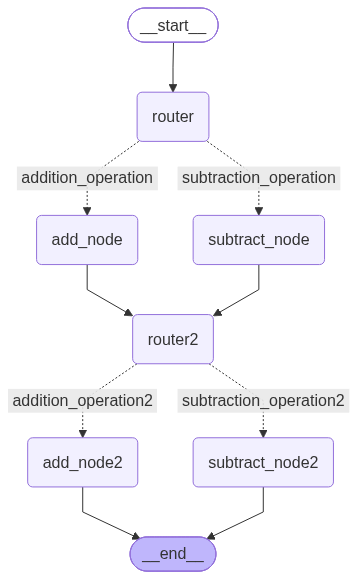

In [35]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [38]:
initial_state = AgentState(
    number1=10,
    operation="-",
    number2=5,

    number3=7,
    operation2="+",
    number4=2
)

print(app.invoke(initial_state))

{'number1': 10, 'operation': '-', 'number2': 5, 'number3': 7, 'operation2': '+', 'number4': 2}


KeyError: 'finalNumber'